In [1]:
# On the basis of the height-weight data I implemented this simple Linear project...

In [2]:
# lets first import some librarys.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline  
# This line mean i can display all matplot lib diagram within this file. 

In [3]:
df = pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


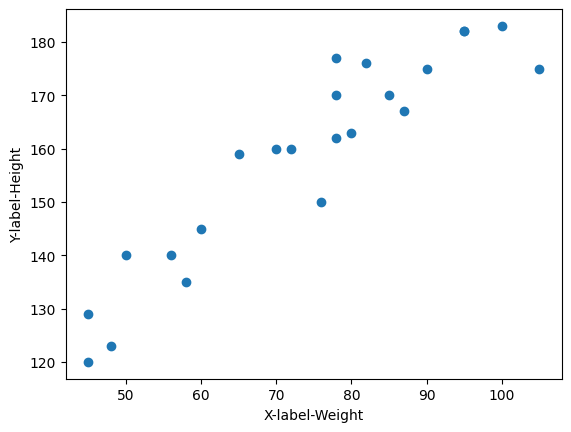

In [4]:
# Now We not did any feature engineering or data cleaning process bcs we already know that it is perefect data.

## Scatter plot
plt.scatter(df['Weight'], df['Height']) 
plt.xlabel('X-label-Weight')
plt.ylabel('Y-label-Height')
plt.show()

In [5]:
# Fingding Correlation btw X-Y
df.corr()  # Internally it uses Pearson-Correlation

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


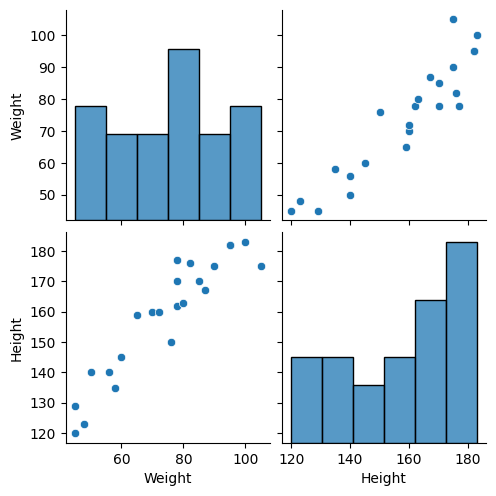

In [7]:
#Seaborn for visulization 
import seaborn as sns 
sns.pairplot(df) # for corr.
plt.show()

In [8]:
# First Step for SLR. (simple linear regression)

# Independant and Dependant Feature

# Always keep in mind that: Your Independant feature always in Dataframe(2-d array) type
X = df[['Weight']]
print(type(X))  # Output: Dataframe
print(np.array(X).shape)  # (23,1)
X.head()

<class 'pandas.core.frame.DataFrame'>
(23, 1)


,Weight
0,45
1,58
2,48
3,60
4,70


In [9]:
X1 = df['Weight']
print(type(X1))  # Output: Series
print(np.array(X1).shape)  # (23,)
X1.head()

<class 'pandas.core.series.Series'>
(23,)


0    45
1    58
2    48
3    60
4    70
Name: Weight, dtype: int64

In [10]:
# Now for dependant 
y = df['Height']  # This Dependant variable can be Series or 1D array
y.head()

0    120
1    135
2    123
3    145
4    160
Name: Height, dtype: int64

In [11]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)
# Test_size of data = 25%
# random_state = 42; it means for all the data chosen same instead of randomly

In [12]:
X_train.shape  # It must be 2-D

(17, 1)

# Important step : Standardization
1. Why ned to apply this: bcs all the features has different-different data type and applying this assential 
2. to make all input_feature in same unit(eg. kg,cm...) and we apply on these features Z_score= (x_i - mue)/s.d. on (mue=0 & sigma=1).
3. By this operation we try to minimize the gredient decent(Loss_fun).

 

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
# See here we used the "fit_tranform" method for "training data-set"

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # standerdiz the training_data
X_train

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [15]:
# See here we used the only "tranform" method; it basically to use the test_data's mean and s.d. which we used
# in z-score now we gone use that here in normal 'trandform' method in its z-score formula internally. 

# why we do that to not gone happen 'Data_leakage'

X_test = scaler.transform(X_test)
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [16]:
# Apply Simple linear regression
from sklearn.linear_model import LinearRegression

In [17]:
regression = LinearRegression(n_jobs=-1)

In [18]:
regression.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [19]:
regression.coef_  # beta_1 value & slop & Cofficient

# What this mean is: 1 unit movement on x-axis leads to 17.29 unit movement on y-axis 

array([17.2982057])

In [20]:
regression.intercept_ # beta_0 & intercept of 156.4 at x=0.

156.47058823529412

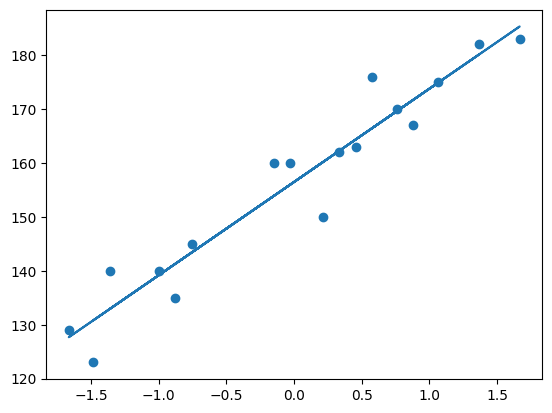

In [21]:
# Plot Trainig data best fit line
plt.scatter(X_train,y_train) 
plt.plot(X_train,regression.predict(X_train))
plt.show()

### prediction of train data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_train =65.4364 + 1.26(X_train)
          
### prediction of test data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_test =65.4364 + 1.26(X_test)

In [21]:
# Prediction for test data
y_pred = regression.predict(X_test)
y_pred

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [22]:
# Performance_metrix

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [23]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.665125886795005
10.716374991212605


## R square 
Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares

In [24]:
from sklearn.metrics import r2_score

In [25]:
score = r2_score(y_test, y_pred)
print(score)

0.7360826717981276


**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [29]:
# Displaying the Adjusted R2

1 - ((1-score)*(len(y_test-1)) / (len(y_test)-X_test.shape[1]-1))

0.6041240076971914

## OLS linear regression

In [30]:
import statsmodels.api as sm

In [31]:
model = sm.OLS(y_train, X_train).fit()

In [32]:
prediction = model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [33]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sun, 03 May 2026   Prob (F-statistic):                       0.664
Time:                        13:17:04   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\Krish\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=17
  res = hypotest_fun_out(*samples, **kwds)


## Prediction for new Data

In [35]:
regression.predict([[72]])

## HAHAHAAAA... this is not correct output see uper before we pass the data we did standardization which we have to do for new data also.

array([1401.94139895])

In [38]:
regression.predict(scaler.transform([[72]]))  # Good

c:\Users\Krish\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])